In [1]:

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import os, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD

# Reset to float32 since no GPU is detected
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
np.random.seed(30)
tf.random.set_seed(30)

import tensorflow as tf

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install kagglehub
import kagglehub
import os

download_path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

local_path = os.path.expanduser("~/garbage_data")

if not os.path.exists(local_path):
    os.symlink(download_path, local_path)
    print(f"Success! Dataset linked to: {local_path}")
else:
    print(f"Note: {local_path} already exists.")

print("Files found:", os.listdir(local_path)[:5], "...")

Note: /home/user/garbage_data already exists.
Files found: ['standardized_384', 'standardized_256', 'original'] ...


---
# PART A — CNNs from Scratch
## Section 2.5.1 — Data Understanding, Analysis, Visualization & Cleaning

In [3]:
from pathlib import Path

DATA_ROOT = Path(os.path.expanduser('~/garbage_data/original'))

# Count Images Per Class
class_counts = {}
all_image_paths = []

for cls_dir in sorted(DATA_ROOT.iterdir()):
    if cls_dir.is_dir():
        imgs = list(cls_dir.iterdir())
        class_counts[cls_dir.name] = len(imgs)
        all_image_paths.extend([(str(p), cls_dir.name) for p in imgs])

total_images = sum(class_counts.values())
CLASS_NAMES  = sorted(class_counts.keys())
NUM_CLASSES  = len(CLASS_NAMES)

print(f'Total images  : {total_images}')
print(f'Num classes   : {NUM_CLASSES}')
print(f'Class names   : {CLASS_NAMES}')

Total images  : 12259
Num classes   : 10
Class names   : ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


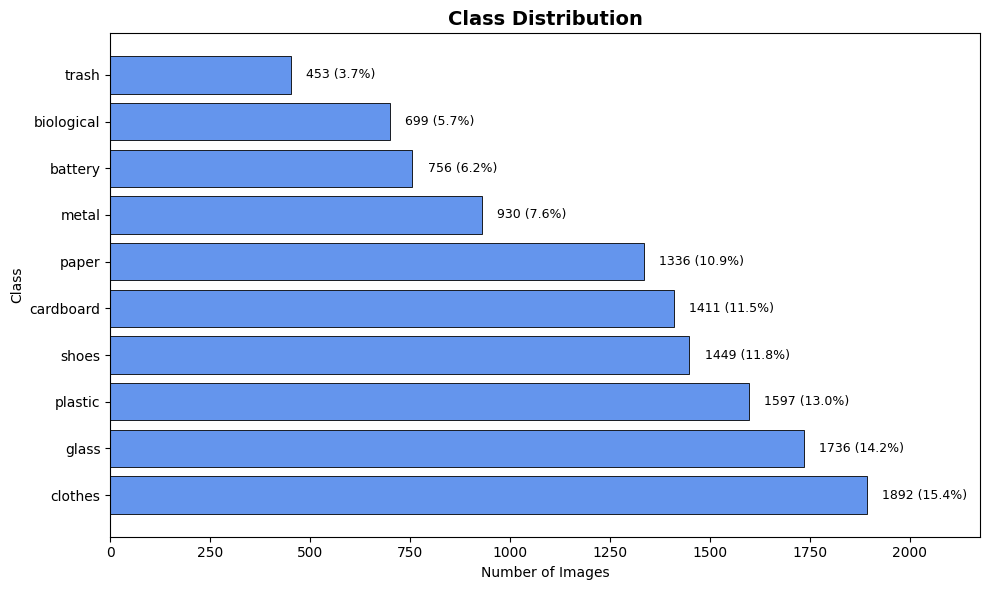


Observation: Dataset distribution across classes is shown with counts and percentages.


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Class Distribution (Horizontal Bar Chart with % + values)

labels = np.array(list(class_counts.keys()))
values = np.array(list(class_counts.values()))

# Sort in ASCENDING order
sorted_idx = np.argsort(values)[::-1]
labels = labels[sorted_idx]
values = values[sorted_idx]

total = values.sum()
percentages = (values / total) * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(labels, values, color='cornflowerblue',
               edgecolor='black', linewidth=0.6)

ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Images')
ax.set_ylabel('Class')

# Add padding so text doesn't go outside
x_pad = max(values) * 0.02
ax.set_xlim(0, max(values) * 1.15)

# Add value + percentage labels
for i, (v, p) in enumerate(zip(values, percentages)):
    ax.text(v + x_pad, i,
            f'{v} ({p:.1f}%)',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('./class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation: Dataset distribution across classes is shown with counts and percentages.')

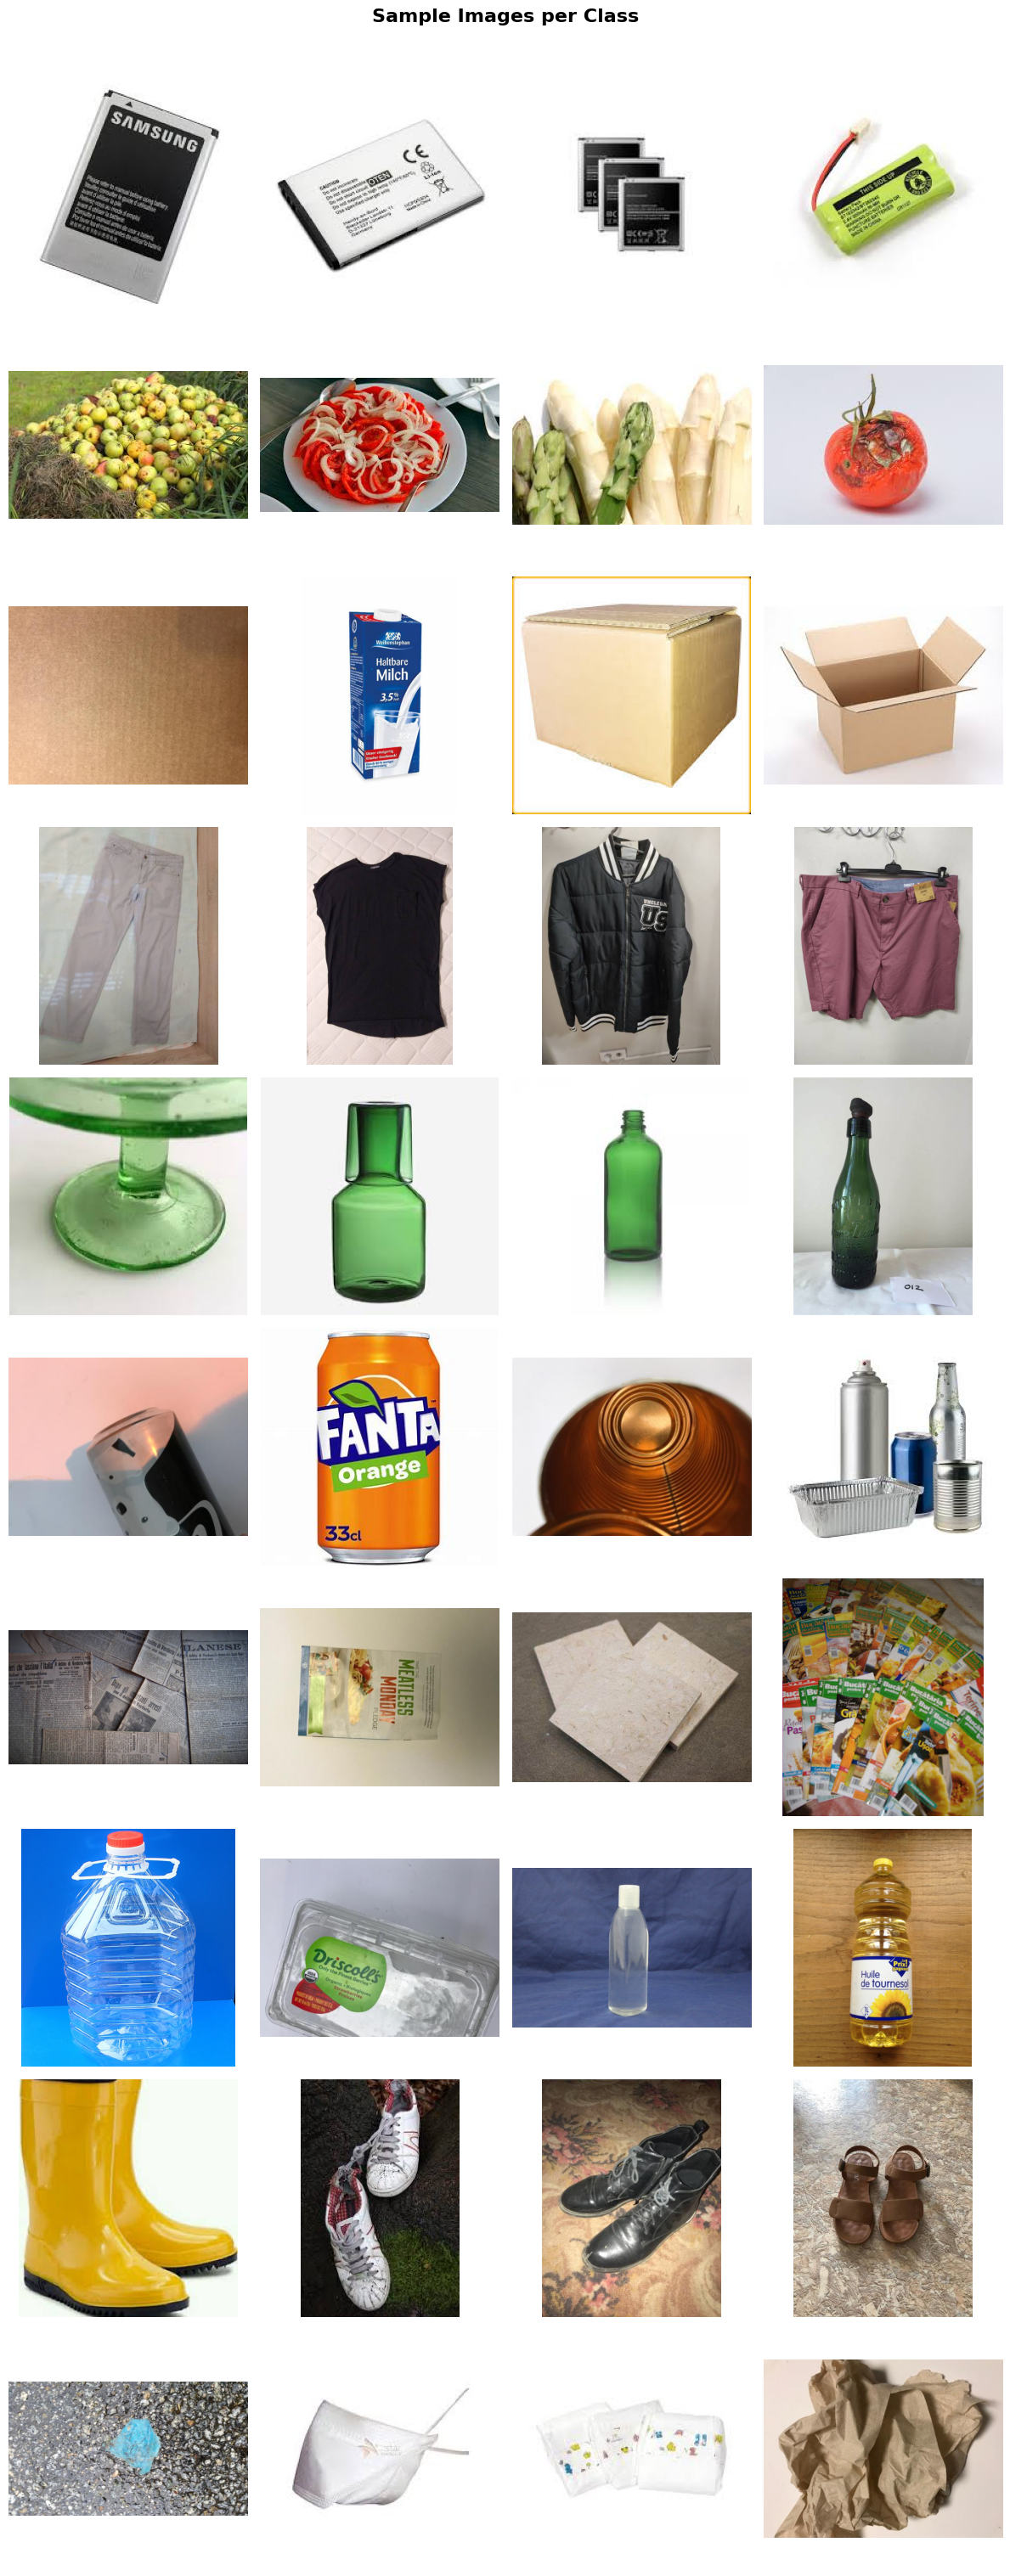

In [5]:
random.seed(30)
n_per_class = 4
fig, axes = plt.subplots(NUM_CLASSES, n_per_class, figsize=(n_per_class * 3, NUM_CLASSES * 3))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    cls_paths = [p for p, c in all_image_paths if c == cls]
    samples   = random.sample(cls_paths, min(n_per_class, len(cls_paths)))
    for col, path in enumerate(samples):
        img = Image.open(path).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=11, fontweight='bold', rotation=0,
                                       labelpad=60, va='center')

plt.tight_layout()
plt.savefig('./sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

In [6]:
import random
import numpy as np
from PIL import Image
import pandas as pd

sample_paths = random.sample(
    [p for p, _ in all_image_paths],
    min(500, total_images)
)

widths, heights = [], []

for path in sample_paths:
    try:
        w, h = Image.open(path).size
        widths.append(w)
        heights.append(h)
    except Exception:
        pass

data = {
    "Metric": ["Width", "Height"],
    "Min": [min(widths), min(heights)],
    "Max": [max(widths), max(heights)],
    "Mean": [np.mean(widths), np.mean(heights)]
}

df = pd.DataFrame(data)

# Display table
print("\nImage Size Summary:\n")
print(df.to_string(index=False, formatters={
    "Mean": "{:.0f}".format
}))


Image Size Summary:

Metric  Min  Max Mean
 Width  133 4056  461
Height  154 5413  447


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT  = 0.20


#  Training Generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale           = 1.0 / 255,
    validation_split  = VAL_SPLIT,
    rotation_range    = 30,
    width_shift_range = 0.2,
    height_shift_range= 0.2,
    shear_range       = 0.15,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    fill_mode         = 'nearest'
)

#  Validation Generator (only rescale)
val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = VAL_SPLIT
)

train_gen = train_datagen.flow_from_directory(
    DATA_ROOT, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=30, shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATA_ROOT, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

print(f'\nTraining samples   : {train_gen.samples}')
print(f'Validation samples : {val_gen.samples}')
print(f'Class indices      : {train_gen.class_indices}')

Found 9811 images belonging to 10 classes.
Found 2448 images belonging to 10 classes.

Training samples   : 9811
Validation samples : 2448
Class indices      : {'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


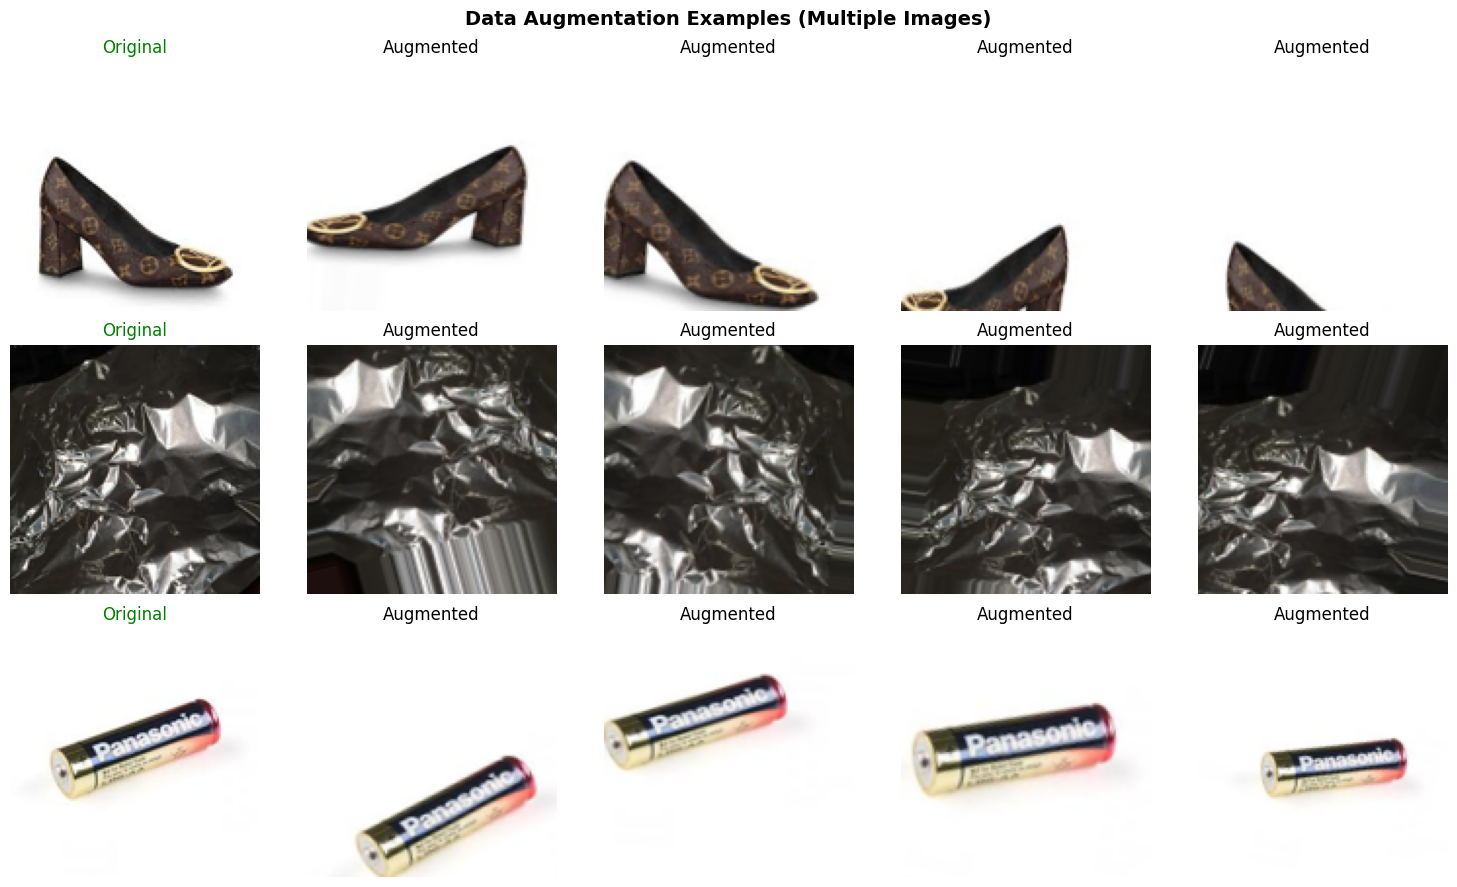

Data augmentation creates diverse variations of multiple images to improve generalization 
 and reduce overfitting.


In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)

aug_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.3,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

num_images = 3
selected_paths = random.sample([p for p, _ in all_image_paths], num_images)

fig, axes = plt.subplots(num_images, 5, figsize=(15, 3 * num_images))
fig.suptitle('Data Augmentation Examples (Multiple Images)', fontsize=14, fontweight='bold')

for i, img_path in enumerate(selected_paths):


    orig_img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    orig_arr = np.array(orig_img) / 255.0


    aug_iter = aug_gen.flow(orig_arr[np.newaxis], batch_size=1)


    axes[i][0].imshow(orig_arr)
    axes[i][0].set_title('Original', color='green')
    axes[i][0].axis('off')


    for j in range(1, 5):
        aug = next(aug_iter)[0]
        axes[i][j].imshow(np.clip(aug, 0, 1))
        axes[i][j].set_title('Augmented')
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig('./augmentation_examples.png', dpi=120, bbox_inches='tight')
plt.show()

print("Data augmentation creates diverse variations of multiple images to improve generalization \n and reduce overfitting.")

---
## Section 2.5.2 — Baseline CNN Model

In [9]:
def build_baseline_model(num_classes, input_shape=(224, 224, 3)):

    model = models.Sequential(name='Baseline_CNN')

    #  Block 1
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    #  Block 2
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    #  Block 3
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Flatten
    model.add(layers.Flatten())

    #  FCN Layers
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))

    #  Output
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


baseline_model = build_baseline_model(NUM_CLASSES)
baseline_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,639,498 (196.99 MB)

 Trainable params: 51,639,498 (196.99 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#  Train Baseline Model
EPOCHS_BASELINE = 25

baseline_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

t0 = time.time()
baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_BASELINE,
    callbacks=baseline_callbacks,
    verbose=1
)
baseline_train_time = time.time() - t0
print(f'\nBaseline training time: {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)')

Epoch 1/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.2613 - loss: 2.4151 - val_accuracy: 0.3938 - val_loss: 1.7506 - learning_rate: 0.0010
Epoch 2/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 72s 235ms/step - accuracy: 0.4119 - loss: 1.6639 - val_accuracy: 0.4861 - val_loss: 1.5021 - learning_rate: 0.0010
Epoch 3/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 74s 242ms/step - accuracy: 0.4553 - loss: 1.5540 - val_accuracy: 0.4910 - val_loss: 1.4751 - learning_rate: 0.0010
Epoch 4/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 73s 236ms/step - accuracy: 0.4986 - loss: 1.4527 - val_accuracy: 0.5323 - val_loss: 1.3468 - learning_rate: 0.0010
Epoch 5/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 68s 222ms/step - accuracy: 0.5146 - loss: 1.4006 - val_accuracy: 0.5417 - val_loss: 1.3253 - learning_rate: 0.0010
Epoch 6/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 70s 228ms/step - accuracy: 0.5360 - loss: 1.3438 - val_accuracy: 0.5596 - val_loss: 1.3006 - learning_rate: 0.0010
Epoch 7/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 69s 225ms/step - accuracy: 0.5

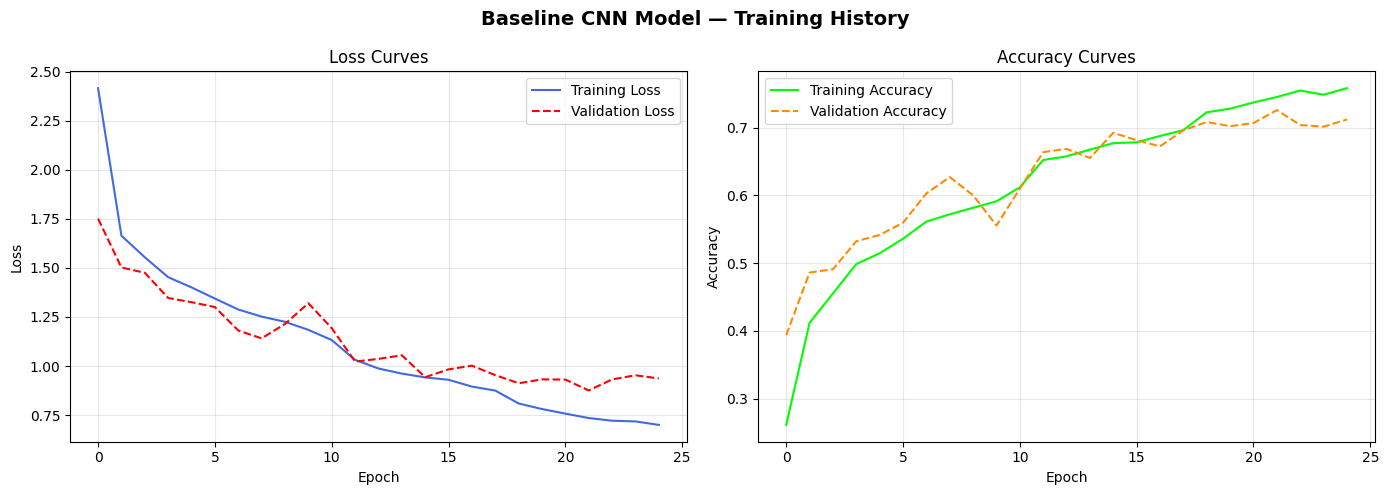

In [11]:
def plot_history(history, title='Model', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title} — Training History', fontsize=14, fontweight='bold')


    axes[0].plot(history.history['loss'],     label='Training Loss',  color='royalblue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss',    color='red', linestyle='--')
    axes[0].set_title('Loss Curves'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)


    axes[1].plot(history.history['accuracy'],     label='Training Accuracy', color='lime')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy',   color='darkorange', linestyle='--')
    axes[1].set_title('Accuracy Curves'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_history(baseline_history, title='Baseline CNN Model', save_path='./baseline_curves.png')


═══════════════════════════════════════════════════════
 Baseline CNN Evaluation Results
═══════════════════════════════════════════════════════
  Accuracy  : 0.7259  (72.59%)
  Precision : 0.7284
  Recall    : 0.7259
  F1-Score  : 0.7249
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

     battery       0.82      0.77      0.80       151
  biological       0.71      0.86      0.78       139
   cardboard       0.81      0.79      0.80       282
     clothes       0.81      0.87      0.83       378
       glass       0.77      0.65      0.71       347
       metal       0.56      0.65      0.60       186
       paper       0.68      0.77      0.72       267
     plastic       0.67      0.62      0.64       319
       shoes       0.72      0.67      0.70       289
       trash       0.57      0.52      0.55        90

    accuracy                           0.73      2448
   macro avg       0.71      0

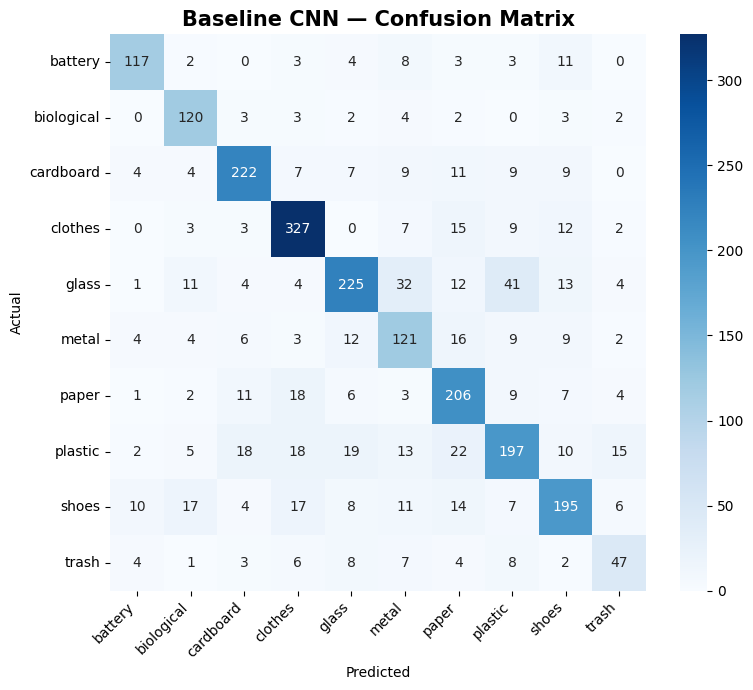

In [12]:
def evaluate_model(model, generator, class_names, model_name='Model'):
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n{"═"*55}')
    print(f' {model_name} Evaluation Results')
    print(f'{"═"*55}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'{"─"*55}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=15, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'./cm_{model_name.replace(" ","_").lower()}.png', dpi=120)
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_true': y_true, 'y_pred': y_pred}


baseline_metrics = evaluate_model(baseline_model, val_gen, CLASS_NAMES, 'Baseline CNN')

---
## Section 2.5.3 — Deeper Architecture with Regularization

In [13]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam

def build_custom_deeper_model(num_classes, input_shape=(224, 224, 3)):

    model = models.Sequential(name='Custom_Deeper_CNN_No_GlobalPooling')

    # Block 1
    model.add(layers.Conv2D(24, (3,3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(24, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D((2,2)))


    # Block 2
    model.add(layers.Conv2D(48, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(48, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D((2,2)))


    # Block 3
    model.add(layers.Conv2D(96, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.Conv2D(96, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    model.add(layers.MaxPooling2D((2,2)))


    # Flatten
    model.add(layers.Flatten())


    # Fully Connected Head
    model.add(layers.Dense(384, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.35))

    model.add(layers.Dense(192, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.25))


    # Output
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


deeper_model = build_custom_deeper_model(NUM_CLASSES)

deeper_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "Custom_Deeper_CNN_No_GlobalPooling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 24)   │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 24)   │         5,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 24)   │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 48)   │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 48)   │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 48)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 48)   │        20,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 48)   │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 48)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 75264)          │             

 Total params: 29,142,946 (111.17 MB)

 Trainable params: 29,141,122 (111.16 MB)

 Non-trainable params: 1,824 (7.12 KB)

In [14]:
from tensorflow.keras import callbacks

EPOCHS_DEEPER = 35

deeper_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
]

t0 = time.time()
deeper_history = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_DEEPER,
    callbacks=deeper_callbacks,
    verbose=1
)
deeper_train_time = time.time() - t0
print(f'\nDeeper model training time: {deeper_train_time:.1f}s ({deeper_train_time/60:.1f} min)')

Epoch 1/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 112s 280ms/step - accuracy: 0.3594 - loss: 2.0959 - val_accuracy: 0.2986 - val_loss: 2.2942 - learning_rate: 0.0010
Epoch 2/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 65s 212ms/step - accuracy: 0.4427 - loss: 1.8411 - val_accuracy: 0.4477 - val_loss: 1.8650 - learning_rate: 0.0010
Epoch 3/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 68s 220ms/step - accuracy: 0.4775 - loss: 1.7500 - val_accuracy: 0.2900 - val_loss: 2.5131 - learning_rate: 0.0010
Epoch 4/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 68s 220ms/step - accuracy: 0.5046 - loss: 1.7093 - val_accuracy: 0.4289 - val_loss: 2.0774 - learning_rate: 0.0010
Epoch 5/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 67s 217ms/step - accuracy: 0.5253 - loss: 1.6651 - val_accuracy: 0.4779 - val_loss: 1.8681 - learning_rate: 0.0010
Epoch 6/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 69s 224ms/step - accuracy: 0.5394 - loss: 1.6491 - val_accuracy: 0.5617 - val_loss: 1.5743 - learning_rate: 0.0010
Epoch 7/35
307/307 ━━━━━━━━━━━━━━━━━━━━ 67s 218ms/step - accuracy: 0.

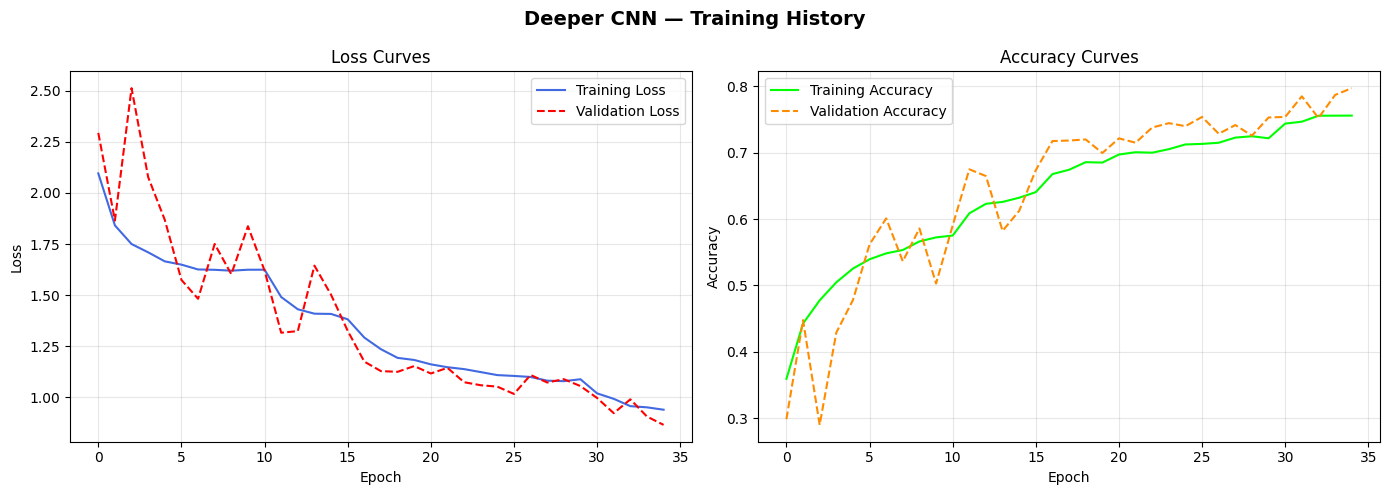

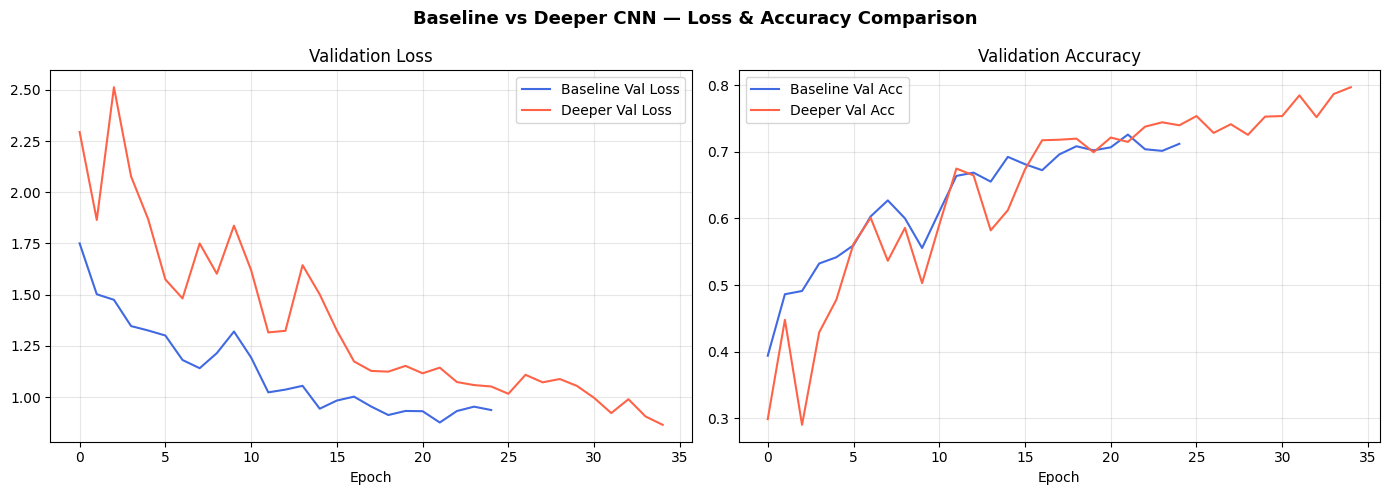

In [15]:
plot_history(deeper_history, title='Deeper CNN', save_path='./deeper_curves.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline vs Deeper CNN — Loss & Accuracy Comparison', fontsize=13, fontweight='bold')

axes[0].plot(baseline_history.history['val_loss'], label='Baseline Val Loss', color='royalblue')
axes[0].plot(deeper_history.history['val_loss'],   label='Deeper Val Loss',   color='tomato')
axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(baseline_history.history['val_accuracy'], label='Baseline Val Acc', color='royalblue')
axes[1].plot(deeper_history.history['val_accuracy'],   label='Deeper Val Acc',   color='tomato')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./comparison_curves.png', dpi=150)
plt.show()


═══════════════════════════════════════════════════════
 Deeper CNN Evaluation Results
═══════════════════════════════════════════════════════
  Accuracy  : 0.7970  (79.70%)
  Precision : 0.7984
  Recall    : 0.7970
  F1-Score  : 0.7944
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

     battery       0.87      0.78      0.82       151
  biological       0.82      0.93      0.87       139
   cardboard       0.84      0.83      0.83       282
     clothes       0.88      0.93      0.91       378
       glass       0.77      0.80      0.79       347
       metal       0.72      0.72      0.72       186
       paper       0.72      0.87      0.79       267
     plastic       0.81      0.61      0.69       319
       shoes       0.81      0.79      0.80       289
       trash       0.63      0.58      0.60        90

    accuracy                           0.80      2448
   macro avg       0.79      0.7

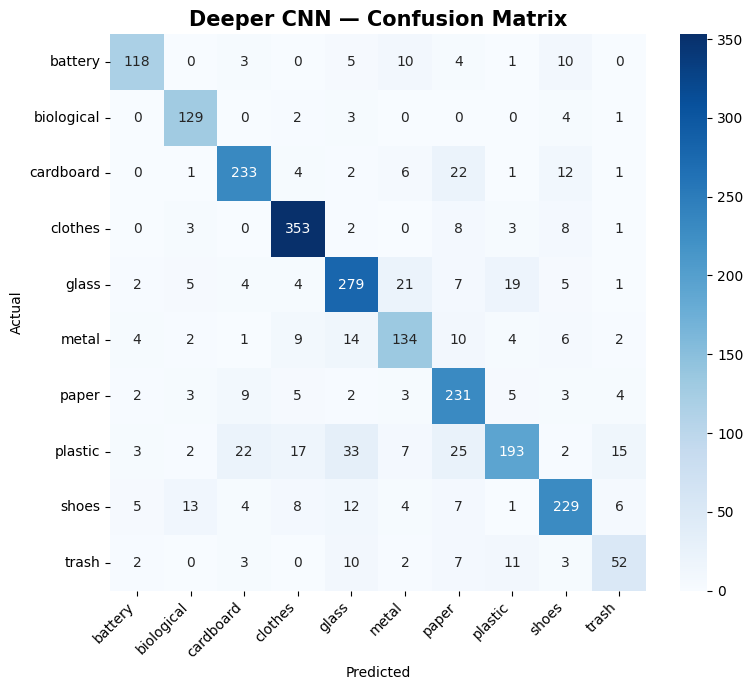

In [16]:
deeper_metrics = evaluate_model(deeper_model, val_gen, CLASS_NAMES, 'Deeper CNN')

---
## Section 2.5.4 — Experimentation and Comparative Analysis

       Model  Accuracy  Precision   Recall  F1-Score  Train Time (s)
Baseline CNN  0.725899   0.728447 0.725899  0.724871     1734.199591
  Deeper CNN  0.796977   0.798427 0.796977  0.794445     2423.660008


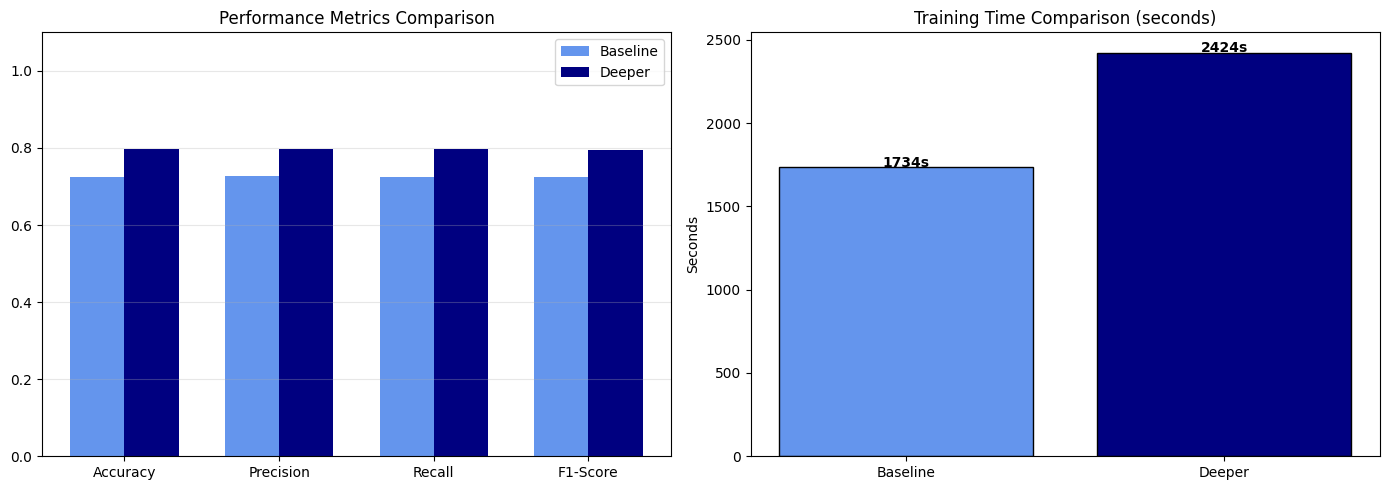

In [24]:
#  1. Baseline vs Deeper: Metric Summary
metrics_df = pd.DataFrame({
    'Model'    : ['Baseline CNN', 'Deeper CNN'],
    'Accuracy' : [baseline_metrics['accuracy'], deeper_metrics['accuracy']],
    'Precision': [baseline_metrics['precision'], deeper_metrics['precision']],
    'Recall'   : [baseline_metrics['recall'], deeper_metrics['recall']],
    'F1-Score' : [baseline_metrics['f1'], deeper_metrics['f1']],
    'Train Time (s)': [baseline_train_time, deeper_train_time]
})
print(metrics_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_to_plot))
w = 0.35

axes[0].bar(x - w/2, metrics_df.loc[0, metrics_to_plot], w, label='Baseline', color='cornflowerblue')
axes[0].bar(x + w/2, metrics_df.loc[1, metrics_to_plot], w, label='Deeper',   color='navy')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylim(0, 1.1); axes[0].set_title('Performance Metrics Comparison')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(['Baseline', 'Deeper'], [baseline_train_time, deeper_train_time],
            color=['cornflowerblue', 'navy'], edgecolor='black')
axes[1].set_title('Training Time Comparison (seconds)')
axes[1].set_ylabel('Seconds')
for i, v in enumerate([baseline_train_time, deeper_train_time]):
    axes[1].text(i, v + 2, f'{v:.0f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./metrics_comparison.png', dpi=150)
plt.show()

Training Deeper CNN with SGD optimizer...
Epoch 1/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 76s 227ms/step - accuracy: 0.3432 - loss: 2.0026 - val_accuracy: 0.2978 - val_loss: 2.1913 - learning_rate: 0.0100
Epoch 2/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 66s 213ms/step - accuracy: 0.4178 - loss: 1.7646 - val_accuracy: 0.4114 - val_loss: 1.8189 - learning_rate: 0.0100
Epoch 3/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 65s 210ms/step - accuracy: 0.4513 - loss: 1.6849 - val_accuracy: 0.4171 - val_loss: 1.8307 - learning_rate: 0.0100
Epoch 4/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 67s 217ms/step - accuracy: 0.4679 - loss: 1.6307 - val_accuracy: 0.4126 - val_loss: 1.7905 - learning_rate: 0.0100
Epoch 5/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 68s 221ms/step - accuracy: 0.4933 - loss: 1.5700 - val_accuracy: 0.4608 - val_loss: 1.6759 - learning_rate: 0.0100
Epoch 6/25
307/307 ━━━━━━━━━━━━━━━━━━━━ 68s 220ms/step - accuracy: 0.5071 - loss: 1.5183 - val_accuracy: 0.4265 - val_loss: 1.8664 - learning_rate: 0.0100
Epoch 7/25
307/307 ━━━━━━━━━

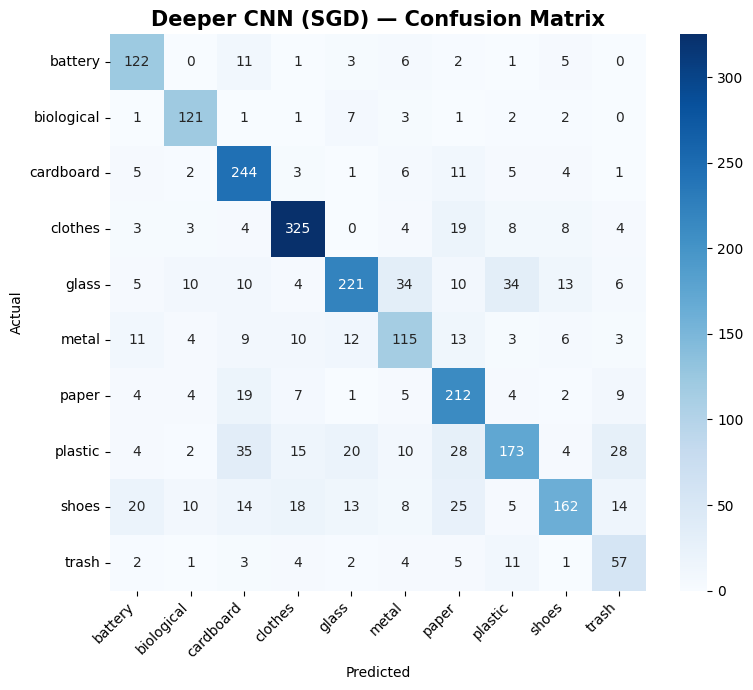

In [20]:
# ── 3. Optimizer Analysis: SGD vs Adam ───────────────────────────────────────
print('Training Deeper CNN with SGD optimizer...')

model_sgd = build_custom_deeper_model(NUM_CLASSES)
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
sgd_history = model_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
    ],
    verbose=1
)
sgd_train_time = time.time() - t0
print(f'SGD training time: {sgd_train_time:.1f}s')

# Evaluate SGD model
sgd_metrics = evaluate_model(model_sgd, val_gen, CLASS_NAMES, 'Deeper CNN (SGD)')

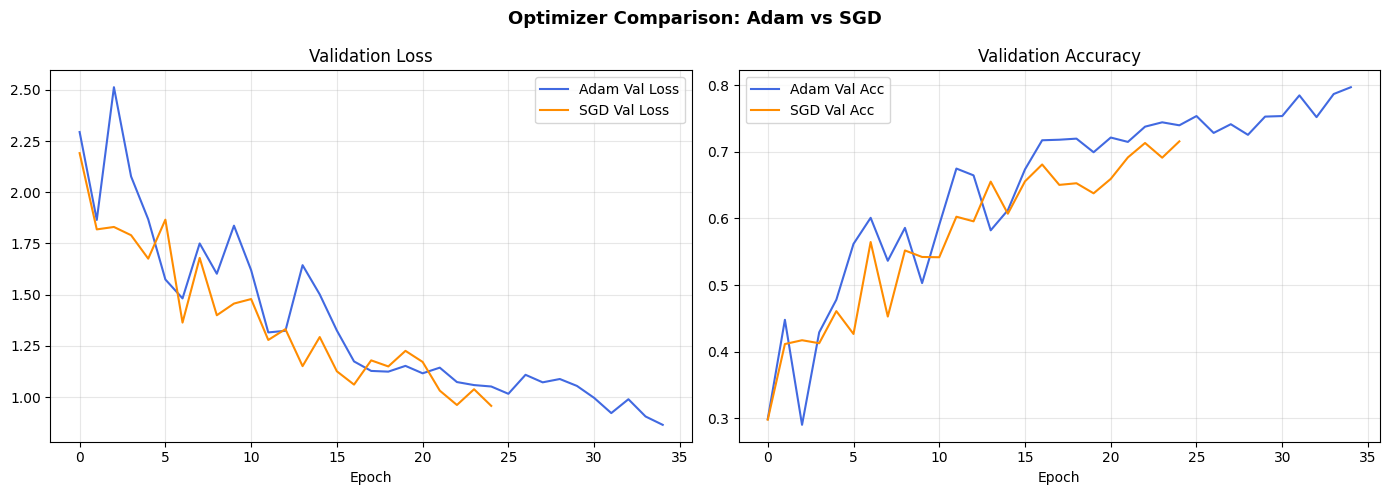


Optimizer Analysis:
  Adam  — Val Acc: 0.7970  | Training Time: 2424s
  SGD   — Val Acc: 0.7157  | Training Time: 1958s

Because of high computational power requirement this process couldnt be done fopr same epoch 
 so a valid comparision could be made 
 but gernally ADAM optimizer are prefered over SGD because of its adaptive learning rate


In [30]:
# Compare Adam vs SGD training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimizer Comparison: Adam vs SGD', fontsize=13, fontweight='bold')

for hist, label, color in [(deeper_history, 'Adam', 'royalblue'), (sgd_history, 'SGD', 'darkorange')]:
    axes[0].plot(hist.history['val_loss'],     label=f'{label} Val Loss',  color=color)
    axes[1].plot(hist.history['val_accuracy'], label=f'{label} Val Acc',   color=color)

axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./optimizer_comparison.png', dpi=150)
plt.show()

print('\nOptimizer Analysis:')
print(f'  Adam  — Val Acc: {deeper_metrics["accuracy"]:.4f}  | Training Time: {deeper_train_time:.0f}s')
print(f'  SGD   — Val Acc: {sgd_metrics["accuracy"]:.4f}  | Training Time: {sgd_train_time:.0f}s')
print()
print("Because of high computational power requirement this process couldnt be done fopr same epoch \n so a valid comparision could be made \n but gernally ADAM optimizer are prefered over SGD because of its adaptive learning rate")

Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 78s 229ms/step - accuracy: 0.3802 - loss: 1.8822 - val_accuracy: 0.1442 - val_loss: 2.8603
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 65s 211ms/step - accuracy: 0.4427 - loss: 1.6500 - val_accuracy: 0.2132 - val_loss: 2.9417
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 65s 211ms/step - accuracy: 0.4920 - loss: 1.5345 - val_accuracy: 0.2941 - val_loss: 2.6535
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 66s 214ms/step - accuracy: 0.5170 - loss: 1.4672 - val_accuracy: 0.2488 - val_loss: 2.6526
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 66s 213ms/step - accuracy: 0.5368 - loss: 1.4012 - val_accuracy: 0.4547 - val_loss: 1.8210
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 66s 215ms/step - accuracy: 0.5611 - loss: 1.3428 - val_accuracy: 0.4538 - val_loss: 1.9189
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 65s 210ms/step - accuracy: 0.5734 - loss: 1.2825 - val_accuracy: 0.4016 - val_loss: 2.0241
Epoch 8/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 66s 213ms/step - accuracy: 0.5935 - loss: 1

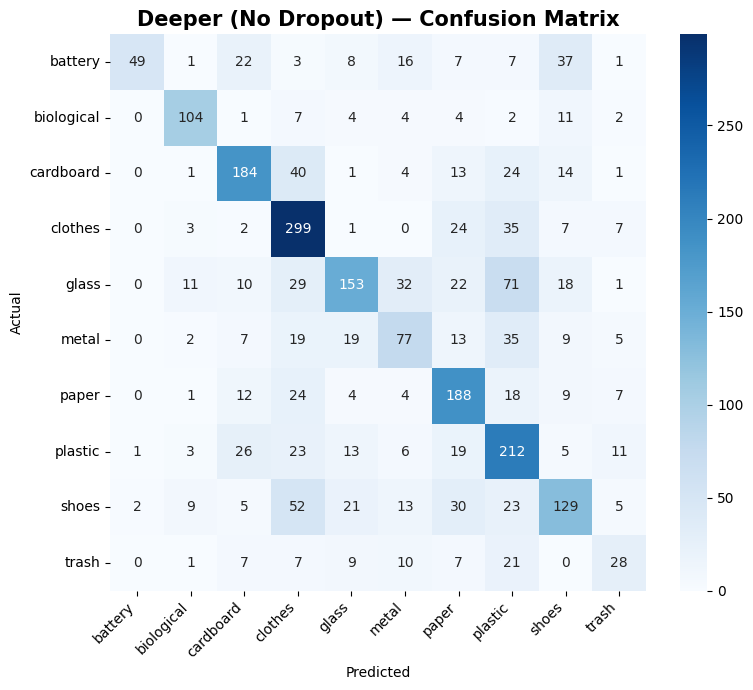


Ablation Study Results:
  With Dropout    — Val Acc: 0.7970
  Without Dropout — Val Acc: 0.5813
  Dropout Contribution: +0.2157

  → Dropout IMPROVES performance: prevents overfitting.


In [31]:
def build_no_dropout_model(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential(name='Deeper_No_Dropout')
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


model_no_drop = build_no_dropout_model(NUM_CLASSES)
model_no_drop.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

ablation_history = model_no_drop.fit(
    train_gen, validation_data=val_gen, epochs=20,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
ablation_metrics = evaluate_model(model_no_drop, val_gen, CLASS_NAMES, 'Deeper (No Dropout)')

print(f'\nAblation Study Results:')
print(f'  With Dropout    — Val Acc: {deeper_metrics["accuracy"]:.4f}')
print(f'  Without Dropout — Val Acc: {ablation_metrics["accuracy"]:.4f}')
diff = deeper_metrics['accuracy'] - ablation_metrics['accuracy']
print(f'  Dropout Contribution: {diff:+.4f}')
print()
if diff > 0:
    print('  → Dropout IMPROVES performance: prevents overfitting.')
else:
    print('  → Without dropout, model may overfit — check train vs val gap.')

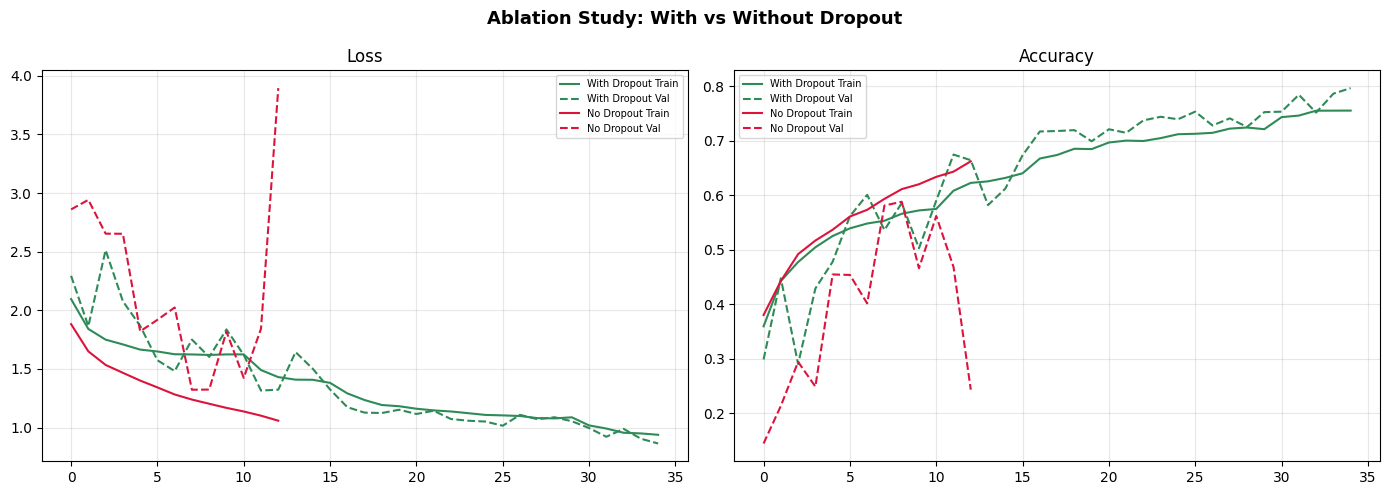

In [32]:
# Ablation: train vs val loss comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study: With vs Without Dropout', fontsize=13, fontweight='bold')

for hist, label, col in [(deeper_history, 'With Dropout', 'seagreen'),
                          (ablation_history, 'No Dropout',  'crimson')]:
    axes[0].plot(hist.history['loss'],         label=f'{label} Train', color=col, linestyle='-')
    axes[0].plot(hist.history['val_loss'],     label=f'{label} Val',   color=col, linestyle='--')
    axes[1].plot(hist.history['accuracy'],     label=f'{label} Train', color=col, linestyle='-')
    axes[1].plot(hist.history['val_accuracy'], label=f'{label} Val',   color=col, linestyle='--')

axes[0].set_title('Loss'); axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)
axes[1].set_title('Accuracy'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./ablation_study.png', dpi=150)
plt.show()

In [33]:
print(f'Baseline Training Time : {baseline_train_time:.1f}s')
print(f'Deeper   Training Time : {deeper_train_time:.1f}s')

Baseline Training Time : 1734.2s
Deeper   Training Time : 2423.7s


---
# PART B — Transfer Learning (Fine-Tuning MobileNetV2)
## Section 2.6.1 — Loading and Adapting a Pre-Trained Model

In [34]:
IMG_SIZE_B = (224, 224)

train_datagen_tl = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split  = 0.20,
    rotation_range    = 30,
    width_shift_range = 0.2,
    height_shift_range= 0.2,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    fill_mode         = 'nearest'
)

val_datagen_tl = ImageDataGenerator(
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split = 0.20
)

train_gen_tl = train_datagen_tl.flow_from_directory(
    DATA_ROOT, target_size=IMG_SIZE_B, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=42, shuffle=True
)

val_gen_tl = val_datagen_tl.flow_from_directory(
    DATA_ROOT, target_size=IMG_SIZE_B, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False
)

print(f'\nTransfer Learning Generators ready.')
print(f'  Train samples : {train_gen_tl.samples}')
print(f'  Val   samples : {val_gen_tl.samples}')
print(f'  Image size    : {IMG_SIZE_B}')
print(f'  Preprocessing : MobileNetV2 built-in (scales pixels to [-1, 1])')

Found 9811 images belonging to 10 classes.
Found 2448 images belonging to 10 classes.

Transfer Learning Generators ready.
  Train samples : 9811
  Val   samples : 2448
  Image size    : (224, 224)
  Preprocessing : MobileNetV2 built-in (scales pixels to [-1, 1])


In [35]:
# ── Build MobileNetV2 — Feature Extraction (Frozen Base) ─────────────────────
print("Why MobileNetV2?")
print("  • Lightweight and efficient — well-suited for relatively small datasets.")
print("  • Pretrained on ImageNet (1.28M images, 1000 classes) → rich features.")
print("  • Depthwise separable convolutions make it faster than VGG/ResNet.")
print()

base_model = MobileNetV2(
    input_shape = IMG_SIZE_B + (3,),
    include_top = False,
    weights     = 'imagenet'
)
base_model.trainable = False   # Freeze all convolutional base layers

# Add custom classification head
inputs  = keras.Input(shape=IMG_SIZE_B + (3,))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_FeatureExtraction')

tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'\nTrainable params    : {tl_model.count_params():,}')
print(f'Frozen base params  : {sum([np.prod(v.shape) for v in base_model.non_trainable_weights]):,}')
tl_model.summary()

Why MobileNetV2?
  • Lightweight and efficient — well-suited for relatively small datasets.
  • Pretrained on ImageNet (1.28M images, 1000 classes) → rich features.
  • Depthwise separable convolutions make it faster than VGG/ResNet.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step

Trainable params    : 2,625,226
Frozen base params  : 2,257,984


Model: "MobileNetV2_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,226 (10.01 MB)

 Trainable params: 364,682 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [36]:

print('Phase 1: Training classification head only (base frozen)...')

t0 = time.time()
tl_history_phase1 = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=15,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ],
    verbose=1
)
tl_phase1_time = time.time() - t0
print(f'Phase 1 training time: {tl_phase1_time:.1f}s')

Phase 1: Training classification head only (base frozen)...
Epoch 1/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 231s 508ms/step - accuracy: 0.7242 - loss: 0.9255 - val_accuracy: 0.8860 - val_loss: 0.3801
Epoch 2/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 65s 212ms/step - accuracy: 0.8344 - loss: 0.5783 - val_accuracy: 0.8991 - val_loss: 0.3494
Epoch 3/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 65s 213ms/step - accuracy: 0.8564 - loss: 0.4896 - val_accuracy: 0.9056 - val_loss: 0.3368
Epoch 4/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 62s 201ms/step - accuracy: 0.8626 - loss: 0.4626 - val_accuracy: 0.9077 - val_loss: 0.3535
Epoch 5/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 64s 207ms/step - accuracy: 0.8784 - loss: 0.4379 - val_accuracy: 0.9167 - val_loss: 0.3353
Epoch 6/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 62s 203ms/step - accuracy: 0.8853 - loss: 0.4129 - val_accuracy: 0.9114 - val_loss: 0.3413
Epoch 7/15
307/307 ━━━━━━━━━━━━━━━━━━━━ 61s 198ms/step - accuracy: 0.8841 - loss: 0.4246 - val_accuracy: 0.9040 - val_loss: 0.3501
Epoch 8/15
307/307 ━━━

In [37]:
print('Phase 2: Fine-tuning — unfreezing top  layers of MobileNetV2...')

base_model.trainable = True
# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
tl_history_phase2 = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=20,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8)
    ],
    verbose=1
)
tl_phase2_time = time.time() - t0
tl_total_time = tl_phase1_time + tl_phase2_time
print(f'Phase 2 training time  : {tl_phase2_time:.1f}s')
print(f'Total TL training time : {tl_total_time:.1f}s ({tl_total_time/60:.1f} min)')

Phase 2: Fine-tuning — unfreezing top  layers of MobileNetV2...
Epoch 1/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 96s 265ms/step - accuracy: 0.8380 - loss: 0.5598 - val_accuracy: 0.9208 - val_loss: 0.3183 - learning_rate: 1.0000e-05
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 70s 227ms/step - accuracy: 0.8633 - loss: 0.4809 - val_accuracy: 0.9191 - val_loss: 0.3177 - learning_rate: 1.0000e-05
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 62s 202ms/step - accuracy: 0.8701 - loss: 0.4592 - val_accuracy: 0.9212 - val_loss: 0.3140 - learning_rate: 1.0000e-05
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 62s 202ms/step - accuracy: 0.8818 - loss: 0.4267 - val_accuracy: 0.9216 - val_loss: 0.3139 - learning_rate: 1.0000e-05
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 63s 205ms/step - accuracy: 0.8831 - loss: 0.4212 - val_accuracy: 0.9163 - val_loss: 0.3110 - learning_rate: 1.0000e-05
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 62s 201ms/step - accuracy: 0.8855 - loss: 0.4063 - val_accuracy: 0.9240 - val_loss: 0.3020 - learning

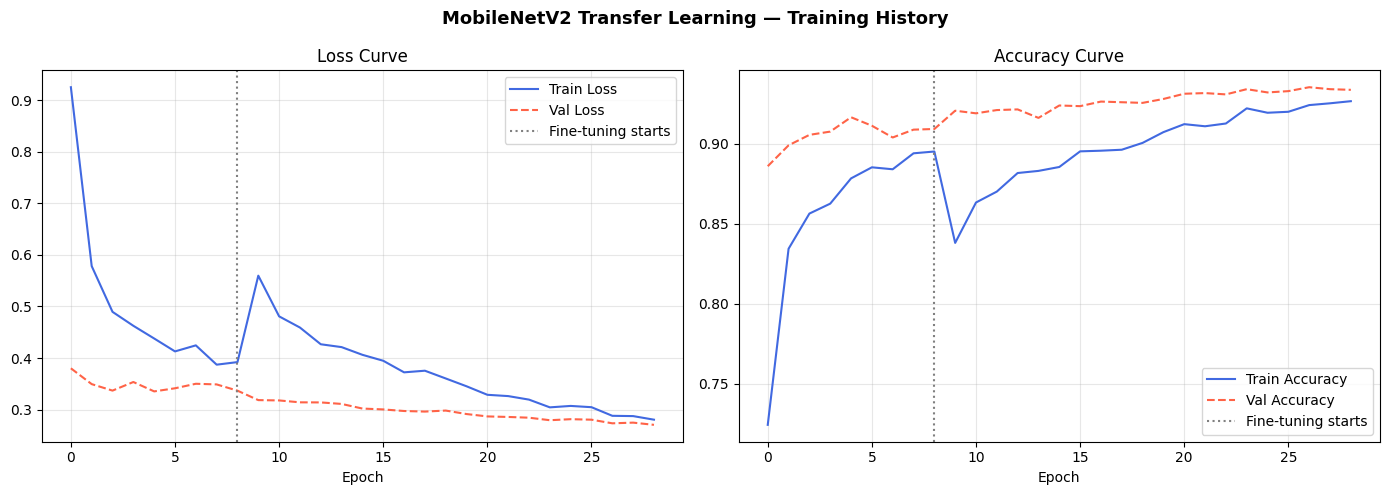

In [38]:
def combine_histories(h1, h2):
    combined = {}
    for k in h1.history:
        combined[k] = h1.history[k] + h2.history[k]
    return combined

combined = combine_histories(tl_history_phase1, tl_history_phase2)
phase1_len = len(tl_history_phase1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 Transfer Learning — Training History', fontsize=13, fontweight='bold')

for ax, metric, title in [(axes[0], 'loss', 'Loss'), (axes[1], 'accuracy', 'Accuracy')]:
    ax.plot(combined[metric],         label=f'Train {title}', color='royalblue')
    ax.plot(combined[f'val_{metric}'], label=f'Val {title}',  color='tomato', linestyle='--')
    ax.axvline(x=phase1_len - 1, color='gray', linestyle=':', label='Fine-tuning starts')
    ax.set_title(f'{title} Curve'); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./tl_training_curves.png', dpi=150)
plt.show()


═══════════════════════════════════════════════════════
 MobileNetV2 TL Evaluation Results
═══════════════════════════════════════════════════════
  Accuracy  : 0.9338  (93.38%)
  Precision : 0.9350
  Recall    : 0.9338
  F1-Score  : 0.9339
───────────────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

     battery       0.96      0.97      0.96       151
  biological       0.98      0.99      0.98       139
   cardboard       0.97      0.89      0.93       282
     clothes       0.99      0.99      0.99       378
       glass       0.93      0.89      0.91       347
       metal       0.84      0.91      0.88       186
       paper       0.88      0.93      0.91       267
     plastic       0.88      0.92      0.90       319
       shoes       0.97      0.98      0.98       289
       trash       0.90      0.81      0.85        90

    accuracy                           0.93      2448
   macro avg       0.93     

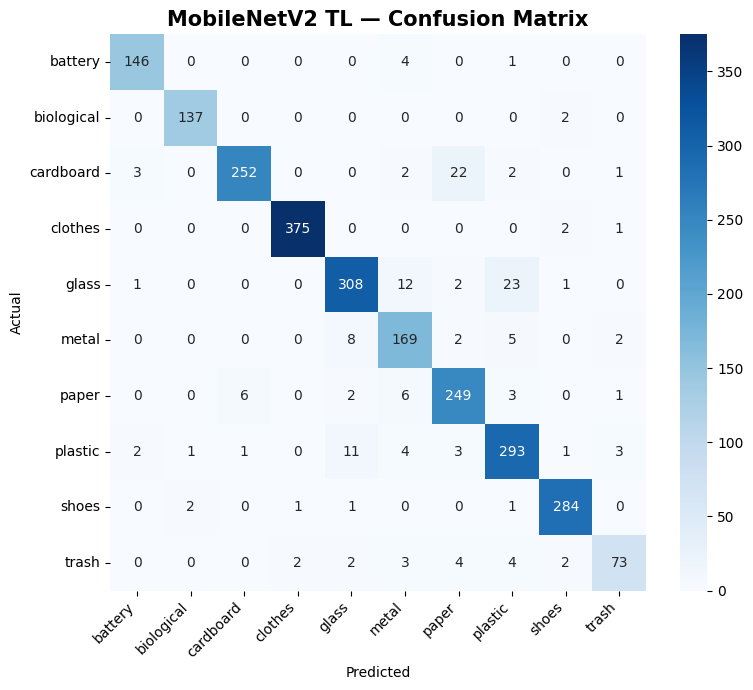

NameError: name 'visualize' is not defined

In [ ]:
tl_metrics = evaluate_model(tl_model, val_gen_tl, CLASS_NAMES, 'MobileNetV2 TL')

FINAL MODEL COMPARISON SUMMARY
            Model  Accuracy  Precision   Recall  F1-Score  Train Time(s)
     Baseline CNN  0.725899   0.728447 0.725899  0.724871    1734.199591
Deeper CNN (Adam)  0.796977   0.798427 0.796977  0.794445    2423.660008
   MobileNetV2 TL  0.933824   0.935049 0.933824  0.933879    2010.139818



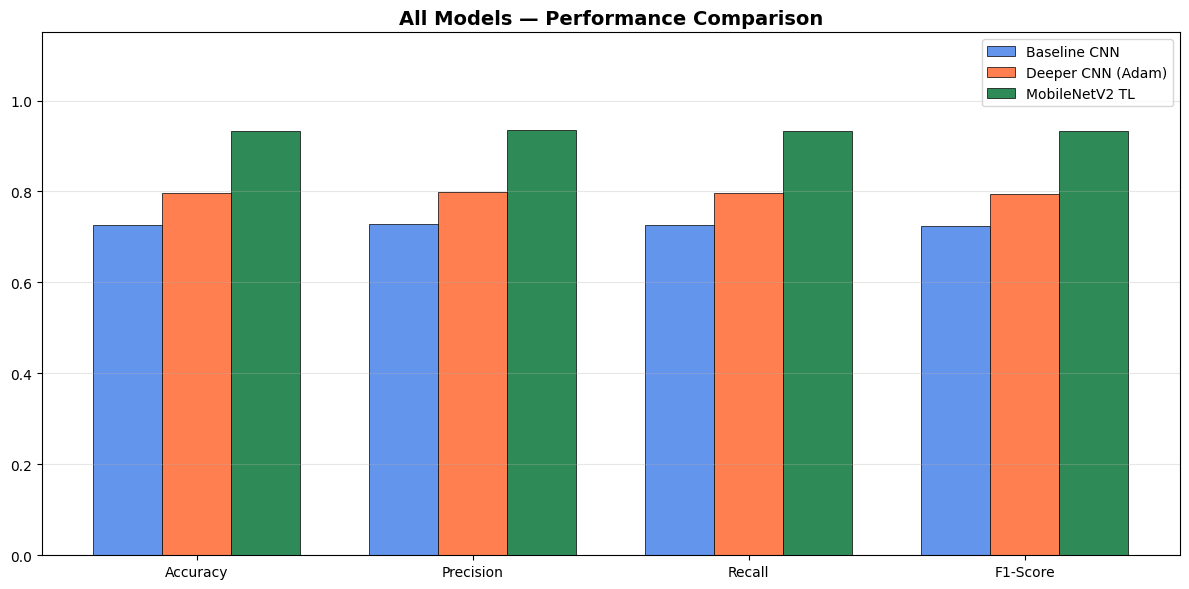

In [41]:
final_df = pd.DataFrame({
    'Model'        : ['Baseline CNN', 'Deeper CNN (Adam)', 'MobileNetV2 TL'],
    'Accuracy'     : [baseline_metrics['accuracy'], deeper_metrics['accuracy'], tl_metrics['accuracy']],
    'Precision'    : [baseline_metrics['precision'], deeper_metrics['precision'], tl_metrics['precision']],
    'Recall'       : [baseline_metrics['recall'], deeper_metrics['recall'], tl_metrics['recall']],
    'F1-Score'     : [baseline_metrics['f1'], deeper_metrics['f1'], tl_metrics['f1']],
    'Train Time(s)': [baseline_train_time, deeper_train_time, tl_total_time]
})

print('='*80)
print('FINAL MODEL COMPARISON SUMMARY')
print('='*80)
print(final_df.to_string(index=False))
print()

# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_cols))
w = 0.25
colors = ['cornflowerblue', 'coral', 'seagreen']

for i, (_, row) in enumerate(final_df.iterrows()):
    ax.bar(x + (i - 1) * w, [row[m] for m in metrics_cols], w,
           label=row['Model'], color=colors[i], edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.15)
ax.set_title('All Models — Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./final_comparison.png', dpi=150)
plt.show()